In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\smart_home_energy_consumption_large.csv")
df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [3]:
plt.style.use('seaborn-v0_8')
df.tail()

,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
99995,124,Microwave,0.42,09:56,2023-09-28,20.5,Summer,1
99996,184,Computer,0.71,12:48,2023-05-27,-5.4,Spring,2
99997,101,Dishwasher,0.25,05:45,2023-02-18,35.6,Winter,3
99998,423,Air Conditioning,2.69,12:39,2023-04-20,3.7,Spring,1
99999,429,Fridge,0.37,18:46,2023-02-27,36.0,Winter,5


In [4]:
df.shape

(100000, 8)

In [5]:
df.info() #summary of dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB


In [6]:
df.isnull().sum() #checks null values

Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
dtype: int64

In [7]:
df.duplicated().sum() #checks duplicates

np.int64(0)

In [8]:
df['Appliance Type'].unique()

array(['Fridge', 'Oven', 'Dishwasher', 'Heater', 'Microwave',
       'Air Conditioning', 'Computer', 'TV', 'Washing Machine', 'Lights'],
      dtype=object)

In [9]:
df['Appliance Type'].value_counts()

Appliance Type
Lights              10201
Dishwasher          10095
Air Conditioning    10067
Heater              10018
Washing Machine      9953
Microwave            9947
Computer             9944
Oven                 9939
Fridge               9931
TV                   9905
Name: count, dtype: int64

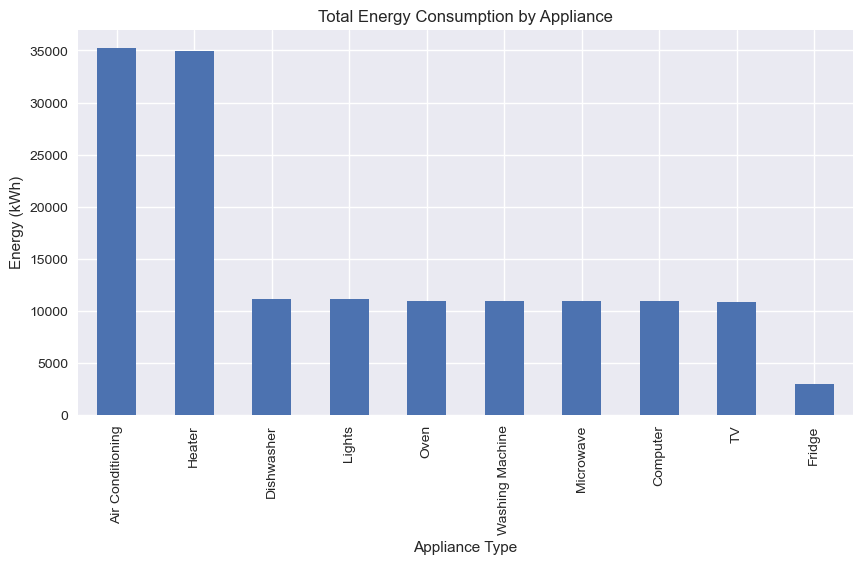

In [10]:
device_energy=df.groupby('Appliance Type')['Energy Consumption (kWh)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
device_energy.plot(kind='bar')
plt.title("Total Energy Consumption by Appliance")
plt.ylabel("Energy (kWh)")
plt.show()

In [11]:
df['Energy Consumption (kWh)'].describe()

count    100000.000000
mean          1.499952
std           1.181176
min           0.100000
25%           0.590000
50%           1.230000
75%           1.870000
max           5.000000
Name: Energy Consumption (kWh), dtype: float64

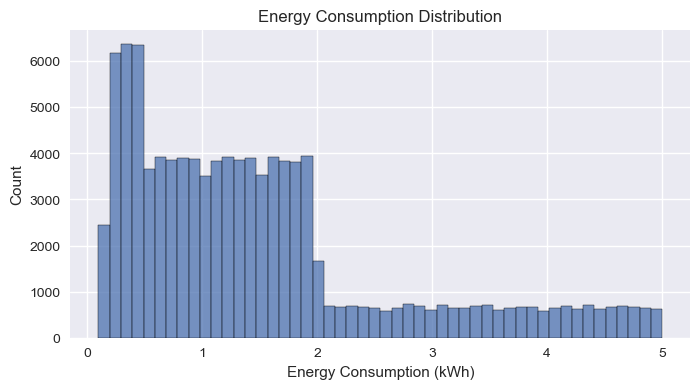

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(df['Energy Consumption (kWh)'],bins=50)
plt.title("Energy Consumption Distribution")
plt.show()

In [15]:
df['timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])



In [16]:
df[['timestamp']].head()

,timestamp
0,2023-12-02 21:12:00
1,2023-08-06 20:11:00
2,2023-11-21 06:39:00
3,2023-01-21 21:56:00
4,2023-08-26 04:31:00


In [17]:
df['timestamp'].dtype

dtype('<M8[ns]')

In [18]:
df=df.drop(['Date','Time'],axis=1)
df=df.set_index('timestamp')


In [19]:
df.index.min(),df.index.max()

(Timestamp('2023-01-01 00:07:00'), Timestamp('2024-01-01 23:53:00'))

In [23]:
df.to_csv(r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Processed\device_level.csv", index=False)


In [26]:
df1=pd.read_csv(r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Processed\device_level.csv")
df1.head()

,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,-1.0,Fall,2
1,435,Oven,0.23,31.1,Summer,5
2,466,Dishwasher,0.32,21.3,Fall,3
3,496,Heater,3.92,-4.2,Winter,1
4,137,Microwave,0.44,34.5,Summer,5


In [27]:
df1.index.dtype

dtype('int64')

In [28]:
df1.isnull().sum()

Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
dtype: int64

In [29]:
df1.duplicated().sum()

np.int64(1)

In [32]:
 df1=df1[~df1.duplicated()] #removing duplicates

In [33]:
(df1['Energy Consumption (kWh)'] < 0).sum()

np.int64(0)

In [34]:
upper_limit=df['Energy Consumption (kWh)'].quantile(0.99)
df1=df1[df1['Energy Consumption (kWh)'] <= upper_limit]


In [35]:
df1['Appliance Type'].unique()

array(['Fridge', 'Oven', 'Dishwasher', 'Heater', 'Microwave',
       'Air Conditioning', 'Computer', 'TV', 'Washing Machine', 'Lights'],
      dtype=object)

In [39]:
hourly_df=(df.groupby('Appliance Type').resample('h')['Energy Consumption (kWh)'].sum().reset_index())

In [40]:
hourly_df.head()

,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01 00:00:00,4.42
1,Air Conditioning,2023-01-01 01:00:00,7.61
2,Air Conditioning,2023-01-01 02:00:00,14.80
3,Air Conditioning,2023-01-01 03:00:00,4.19
4,Air Conditioning,2023-01-01 04:00:00,10.68


In [41]:
hourly_df.shape

(87828, 3)

In [42]:
daily_df=(df.groupby('Appliance Type').resample('D')['Energy Consumption (kWh)'].sum().reset_index())

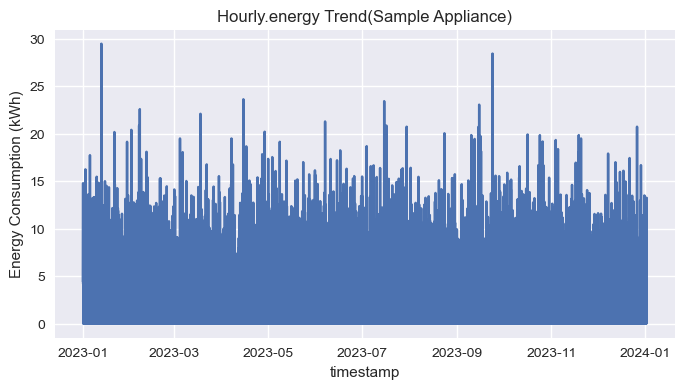

In [43]:
plt.figure(figsize=(8,4))
sns.lineplot(
    data=hourly_df[hourly_df['Appliance Type']==hourly_df['Appliance Type'].iloc[0]],
    x='timestamp',
    y='Energy Consumption (kWh)'
)
plt.title("Hourly.energy Trend(Sample Appliance)")
plt.show()

In [44]:
hourly_df.to_csv(r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Processed\hourly_device_energy.csv", index=False)
daily_df.to_csv(r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Processed\daily_device_energy.csv", index=False)

In [45]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df1['Energy Consumption (kWh)']=scaler.fit_transform(df1[['Energy Consumption (kWh)']])
print(df1['Energy Consumption (kWh)'])

0        0.021053
1        0.027368
2        0.046316
3        0.804211
4        0.071579
           ...   
99995    0.067368
99996    0.128421
99997    0.031579
99998    0.545263
99999    0.056842
Name: Energy Consumption (kWh), Length: 99048, dtype: float64


In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df1['Energy Consumption (kWh)'] = scaler.fit_transform(
    df1[['Energy Consumption (kWh)']]
)
print(df1['Energy Consumption (kWh)'].head())


0   -1.113572
1   -1.087206
2   -1.008108
3    2.155811
4   -0.902644
Name: Energy Consumption (kWh), dtype: float64
